# Imports

In [3]:
import xarray as xr
import numpy as np
import xeofs as xe
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import cartopy.util as cutil
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import colormaps as cmaps
from scipy.stats import t

In [4]:
ds = xr.open_dataset('/glade/work/acruz/E3SMv2LE/E3SMv2_hist_SSTs.nc')

In [5]:
ds

<xarray.Dataset> Size: 9GB
Dimensions:  (lat: 192, lon: 288, time: 1980, member: 21)
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
    lev      float64 8B ...
  * time     (time) object 16kB 1850-02-01 00:00:00 ... 2015-01-01 00:00:00
Dimensions without coordinates: member
Data variables:
    T        (member, time, lat, lon) float32 9GB ...

# Data select

In [6]:
# time = 101 years * 12 months = 1,212
ds = ds.sel(time=slice('1914-01-01', '2014-12-01'))
# ds = ds.sel(time=slice('1920-01-01', '2014-12-01'))
# Easier and faster to shift lons to -180, 180
ds.coords['lon'] = (ds.coords['lon'] + 180) % 360 - 180
ds = ds.sortby(ds.lon)

# roll data and then assign coords, to avoid using where
ATL_ds = ds.sel(lat=slice(-10, 10), lon=slice(-60, 20))

ds = ds.assign_coords({'member': ds['member']})
ATL_ds = ATL_ds.assign_coords({'member': ATL_ds['member']})
ATL_ds

<xarray.Dataset> Size: 146MB
Dimensions:  (lat: 22, time: 1212, member: 21, lon: 65)
Coordinates:
  * lat      (lat) float64 176B -9.895 -8.953 -8.01 -7.068 ... 8.01 8.953 9.895
    lev      float64 8B ...
  * time     (time) object 10kB 1914-01-01 00:00:00 ... 2014-12-01 00:00:00
  * lon      (lon) float64 520B -60.0 -58.75 -57.5 -56.25 ... 17.5 18.75 20.0
  * member   (member) int64 168B 0 1 2 3 4 5 6 7 8 ... 13 14 15 16 17 18 19 20
Data variables:
    T        (member, time, lat, lon) float32 146MB ...

# Anomalies

In [7]:
clim = ATL_ds.groupby('time.month').mean(dim='time')

In [8]:
anom = ATL_ds.groupby('time.month') - clim

In [9]:
# change var name to SST
anom = anom.rename_vars({'T': 'SST'})
anom

<xarray.Dataset> Size: 146MB
Dimensions:  (lat: 22, time: 1212, lon: 65, member: 21)
Coordinates:
  * lat      (lat) float64 176B -9.895 -8.953 -8.01 -7.068 ... 8.01 8.953 9.895
    lev      (time) float64 10kB 998.5 998.5 998.5 998.5 ... 998.5 998.5 998.5
  * time     (time) object 10kB 1914-01-01 00:00:00 ... 2014-12-01 00:00:00
  * lon      (lon) float64 520B -60.0 -58.75 -57.5 -56.25 ... 17.5 18.75 20.0
  * member   (member) int64 168B 0 1 2 3 4 5 6 7 8 ... 13 14 15 16 17 18 19 20
    month    (time) int64 10kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    SST      (member, time, lat, lon) float32 146MB nan nan nan ... nan nan nan

# Detrend
Remove later if we decide on it

In [10]:
def detrend_dim(da, dim, deg=1):
    # detrend along a single dimension
    p = da.polyfit(dim=dim, deg=deg)
    fit = xr.polyval(da[dim], p.polyfit_coefficients)
    return da - fit


anom_dtrend = detrend_dim(anom['SST'], dim='time')
anom_dtrend

<xarray.DataArray (member: 21, time: 1212, lat: 22, lon: 65)> Size: 291MB
array([[[[        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         ...,
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,  0.39915739, ...,         nan,
                  nan,         nan],
         [        nan,  0.34493735,  0.36608566, ...,         nan,
                  nan,         nan]],

        [[        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
...
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,  0.6981993 , ...,         nan,
                  nan,         nan],
         [        nan,  0.78828286,  0.67609507, ...,         nan,
                  nan,         nan]],

        [[        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         ...,
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,  0.69279152, ...,         nan,
                  nan,         nan],
         [        nan,  0.77394272,  0.71969762, ...,         nan,
                  nan,         nan]]]])
Coordinates:
  * lat      (lat) float64 176B -9.895 -8.953 -8.01 -7.068 ... 8.01 8.953 9.895
    lev      (time) float64 10kB 998.5 998.5 998.5 998.5 ... 998.5 998.5 998.5
  * time     (time) object 10kB 1914-01-01 00:00:00 ... 2014-12-01 00:00:00
  * lon      (lon) float64 520B -60.0 -58.75 -57.5 -56.25 ... 17.5 18.75 20.0
  * member   (member) int64 168B 0 1 2 3 4 5 6 7 8 ... 13 14 15 16 17 18 19 20
    month    (time) int64 10kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12

# EOF

In [11]:
%%time
'''
Members are not kept separate from decomposoition and its loosing the dimension after the fit

model.scores() not returning list of DataArray in same way as model.components
from source code the type annotation is dataarray instead of DataObject

as alternative I will simply loop through members and call a  new fit everytime
'''
anom_members = [anom_dtrend.sel(member=m) for m in anom_dtrend['member']]

EOF_members = []
for m in anom_members:
    model = xe.single.EOF(n_modes=3, use_coslat=True)
    model.fit(m, dim='time')
    components = model.components()
    PCs = model.scores(normalized=False)
    xplained_var = model.explained_variance_ratio()
    member_result = xr.Dataset({'components' : components, 'PCs' : PCs, 'ex_var' : xplained_var})
    EOF_members.append(member_result)

EOF_members = xr.concat(EOF_members, dim='member')
EOF_members

CPU times: user 1.29 s, sys: 66.6 ms, total: 1.35 s
Wall time: 1.45 s


<xarray.Dataset> Size: 1MB
Dimensions:     (member: 21, mode: 3, lat: 22, lon: 65, time: 1212)
Coordinates:
  * lat         (lat) float64 176B -9.895 -8.953 -8.01 ... 8.01 8.953 9.895
  * lon         (lon) float64 520B -60.0 -58.75 -57.5 -56.25 ... 17.5 18.75 20.0
  * mode        (mode) int64 24B 1 2 3
  * member      (member) int64 168B 0 1 2 3 4 5 6 7 ... 13 14 15 16 17 18 19 20
    lev         (time) float64 10kB 998.5 998.5 998.5 ... 998.5 998.5 998.5
  * time        (time) object 10kB 1914-01-01 00:00:00 ... 2014-12-01 00:00:00
    month       (time) int64 10kB 1 2 3 4 5 6 7 8 9 10 ... 4 5 6 7 8 9 10 11 12
Data variables:
    components  (member, mode, lat, lon) float64 721kB nan nan nan ... nan nan
    PCs         (member, mode, time) float64 611kB 9.997 8.305 ... 2.418 2.096
    ex_var      (member, mode) float64 504B 0.4733 0.2372 ... 0.2422 0.07354

# Scaling and normalizing

In [12]:
pc_std = EOF_members['PCs'].std(dim='time')
pc_mean = EOF_members['PCs'].mean(dim='time')

In [13]:
normalized_PCs = (EOF_members['PCs'] - pc_mean) / pc_std
scaled_EOF = EOF_members['components'] * pc_std

In [14]:
normalized_PCs

<xarray.DataArray 'PCs' (member: 21, mode: 3, time: 1212)> Size: 611kB
array([[[ 1.28700338e+00,  1.06910630e+00,  7.47014841e-01, ...,
         -5.39040564e-01, -1.79630022e-01,  1.55920846e-01],
        [-7.32828195e-01, -3.22027601e-01,  9.15618848e-01, ...,
         -2.41340139e+00, -1.76044888e+00, -1.48264065e+00],
        [ 8.35556511e-01,  9.86247444e-01, -4.26369167e-04, ...,
         -1.42817720e+00, -7.51506293e-03,  2.72633587e-01]],

       [[-2.28938715e-01, -5.18293596e-01, -1.03804896e-01, ...,
          7.88101142e-01,  3.64314113e-01,  5.85614680e-01],
        [ 1.21182972e+00,  8.68857742e-01,  9.96817653e-01, ...,
          6.71084778e-02,  6.30753585e-01,  2.14213323e-01],
        [-5.69228118e-01, -2.92666731e-01,  2.07723284e-01, ...,
         -6.67456883e-01, -1.16466878e+00, -3.84622982e-01]],

       [[-2.91612491e-01, -1.54446255e+00, -1.32005985e+00, ...,
          8.02306230e-01,  6.07910120e-01,  1.77735739e-02],
        [ 4.37129802e-01,  8.35359927e-01,  4.05721061e-01, ...,
         -9.46298006e-01, -6.77443810e-01, -6.12598076e-01],
        [ 3.09507590e-01, -1.06964310e+00, -5.67541567e-01, ...,
          3.28097357e-02, -4.87529560e-01,  3.78955357e-01]],
...
       [[ 9.90424766e-01,  3.11650339e-01,  4.18396233e-01, ...,
          1.10153605e+00,  6.16717156e-01,  3.58282219e-01],
        [ 9.92546338e-01,  4.62625146e-01,  2.89571292e-01, ...,
          4.67259721e-01,  2.79931031e-01, -3.16706319e-01],
        [-3.86130590e-01,  3.13501276e-01, -3.25348915e-01, ...,
         -9.08976284e-01, -2.29217021e-01, -3.79734684e-01]],

       [[-6.61840207e-01, -1.36435732e+00,  4.62752701e-02, ...,
          3.85184535e-01,  6.18024564e-01, -3.22065366e-01],
        [-2.11735754e-01, -1.86686850e-01, -1.92761047e-01, ...,
          1.08256797e+00,  4.67999755e-01,  4.24630893e-01],
        [-3.26096782e-01, -3.12579512e-01, -9.44742535e-01, ...,
          9.97129801e-01,  3.35339613e-01,  2.55548053e-01]],

       [[ 1.63635177e+00,  1.15151192e+00,  7.19099835e-01, ...,
          1.20400148e+00,  7.21755847e-01,  5.26137916e-01],
        [-1.12642806e+00, -8.64276070e-01, -7.84636328e-01, ...,
          6.21690614e-01,  1.11869162e+00,  9.94641839e-01],
        [-1.64792294e+00, -1.44557277e+00, -1.04911070e+00, ...,
          5.97114319e-01,  7.89726241e-01,  6.84478971e-01]]])
Coordinates:
  * mode     (mode) int64 24B 1 2 3
  * member   (member) int64 168B 0 1 2 3 4 5 6 7 8 ... 13 14 15 16 17 18 19 20
    lev      (time) float64 10kB 998.5 998.5 998.5 998.5 ... 998.5 998.5 998.5
  * time     (time) object 10kB 1914-01-01 00:00:00 ... 2014-12-01 00:00:00
    month    (time) int64 10kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Attributes: (12/15)
    model:          EOF analysis
    software:       xeofs
    version:        3.0.4
    date:           2025-09-05 07:19:57
    n_modes:        3
    center:         True
    ...             ...
    sample_name:    sample
    feature_name:   feature
    random_state:   None
    compute:        True
    solver:         auto
    solver_kwargs:  {}

# CANI and EANI

In [15]:
PC1 = normalized_PCs.sel(mode=1)
PC3 = normalized_PCs.sel(mode=3)

EOF1 = scaled_EOF.sel(mode=1)
EOF3 = scaled_EOF.sel(mode=3)

EAN = (EOF1 + EOF3) / (2 ** 0.5)
CAN = (EOF1 - EOF3) / (2 ** 0.5)

EANI = (PC1 + PC3) / (2 ** 0.5)
CANI = (PC1 - PC3) / (2 ** 0.5)

# using 5 months as in literature
roll = 5
EANI_roll = EANI.rolling(time=roll, center=True).mean()
CANI_roll = CANI.rolling(time=roll, center=True).mean()

In [16]:
EANI_roll

<xarray.DataArray 'PCs' (member: 21, time: 1212)> Size: 204kB
array([[        nan,         nan,  0.76808679, ..., -0.75479964,
                nan,         nan],
       [        nan,         nan, -0.03163629, ..., -0.05640253,
                nan,         nan],
       [        nan,         nan, -0.51854131, ...,  0.49321747,
                nan,         nan],
       ...,
       [        nan,         nan,  0.09055911, ...,  0.32145105,
                nan,         nan],
       [        nan,         nan, -0.2903797 , ...,  0.71038629,
                nan,         nan],
       [        nan,         nan, -0.35637517, ...,  1.05643663,
                nan,         nan]])
Coordinates:
  * member   (member) int64 168B 0 1 2 3 4 5 6 7 8 ... 13 14 15 16 17 18 19 20
    lev      (time) float64 10kB 998.5 998.5 998.5 998.5 ... 998.5 998.5 998.5
  * time     (time) object 10kB 1914-01-01 00:00:00 ... 2014-12-01 00:00:00
    month    (time) int64 10kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Attributes: (12/15)
    model:          EOF analysis
    software:       xeofs
    version:        3.0.4
    date:           2025-09-05 07:19:57
    n_modes:        3
    center:         True
    ...             ...
    sample_name:    sample
    feature_name:   feature
    random_state:   None
    compute:        True
    solver:         auto
    solver_kwargs:  {}

# Variances

In [17]:
# select only the summer of the index
EANI_JJA = EANI_roll.where(EANI_roll.time.dt.month.isin([6, 7, 8]), drop=True)
CANI_JJA = CANI_roll.where(CANI_roll.time.dt.month.isin([6, 7, 8]), drop=True)

EANI_JJA_mean = EANI_JJA.groupby('time.year').mean()
CANI_JJA_mean = CANI_JJA.groupby('time.year').mean()

var_roll = 21
EANI_var = EANI_JJA_mean.rolling(year=var_roll, center=True).var()
CANI_var = CANI_JJA_mean.rolling(year=var_roll, center=True).var()

CvE_r = CANI_var / EANI_var

# Plotting

## View data

In [18]:
EAN

<xarray.DataArray (member: 21, lat: 22, lon: 65)> Size: 240kB
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan, 0.17820968, ...,        nan,
                nan,        nan],
        [       nan, 0.17077108, 0.17542021, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan, 0.15644327, ...,        nan,
                nan,        nan],
        [       nan, 0.14880292, 0.15280264, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan, 0.1962132 , ...,        nan,
                nan,        nan],
        [       nan, 0.19671846, 0.197872  , ...,        nan,
                nan,        nan]]])
Coordinates:
  * lat      (lat) float64 176B -9.895 -8.953 -8.01 -7.068 ... 8.01 8.953 9.895
  * lon      (lon) float64 520B -60.0 -58.75 -57.5 -56.25 ... 17.5 18.75 20.0
  * member   (member) int64 168B 0 1 2 3 4 5 6 7 8 ... 13 14 15 16 17 18 19 20
Attributes: (12/15)
    model:          EOF analysis
    software:       xeofs
    version:        3.0.4
    date:           2025-09-05 07:19:57
    n_modes:        3
    center:         True
    ...             ...
    sample_name:    sample
    feature_name:   feature
    random_state:   None
    compute:        True
    solver:         auto
    solver_kwargs:  {}

## Map function

In [19]:
def ds_map(ds_to_plt, bounds=[20, -60, 10, -10], name='figure'):
    fig, ax = plt.subplots(1, 1,
                           subplot_kw={'projection': ccrs.PlateCarree()})
    fig.subplots_adjust(hspace=0, wspace=0, top=0.925, left=0.1)
    cbar_ax = fig.add_axes([0, 0, 0.1, 0.1])
    cdat, clon = cutil.add_cyclic_point(ds_to_plt, ds_to_plt.lon)

    ax.set_title(name)
    lat_ticks = np.arange(bounds[3], bounds[2], 5)
    lon_ticks = np.arange(bounds[1], bounds[0], 10)
    ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
    lon_formatter = LongitudeFormatter(zero_direction_label=True)
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)
    ax.add_feature(cf.LAND)


    def resize_colobar(event):
        plt.draw()
        posn = ax.get_position()
        cbar_ax.set_position([posn.x0 + posn.width + 0.01, posn.y0,
                              0.04, posn.height])

    ax.set_extent(bounds, ccrs.PlateCarree())
    sst_contour = ax.contourf(clon, ds_to_plt.lat, cdat,
                              levels=np.arange(-0.4, 0.5, 0.05),
                              # levels=40,
                              transform=ccrs.PlateCarree(), cmap='inferno', extend='both')
    fig.canvas.mpl_connect('resize_event', resize_colobar)
    ax.coastlines()
    plt.colorbar(sst_contour, cax=cbar_ax)
    resize_colobar(None)
    # plt.savefig(name, dpi=300)
    return fig, ax


def reg_map(ds_to_plt, significance, bounds=[20, -60, 10, -10], name='figure',
           color=cmaps.posneg_1,
           lev=np.arange(-1.5, 1.5, 0.15)):

    fig, ax = plt.subplots(1, 1,
                           subplot_kw={'projection': ccrs.PlateCarree()})
    fig.subplots_adjust(hspace=0, wspace=0, top=0.925, left=0.1)
    cbar_ax = fig.add_axes([0, 0, 0.1, 0.1])
    cdat, clon = cutil.add_cyclic_point(ds_to_plt, ds_to_plt.lon)
    csig, csig_lon = cutil.add_cyclic_point(significance, significance.lon)

    ax.set_title(name)
    lat_ticks = np.arange(bounds[3], bounds[2], 30)
    lon_ticks = np.arange(bounds[1], bounds[0], 60)
    ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
    lon_formatter = LongitudeFormatter(zero_direction_label=True)
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)
    ax.add_feature(cf.LAND)

# local function because it modifies local objects
    def resize_colobar(event):
        plt.draw()
        posn = ax.get_position()
        cbar_ax.set_position([posn.x0 + posn.width + 0.01, posn.y0,
                              0.04, posn.height])

    ax.set_extent(bounds, ccrs.PlateCarree())
    sst_contour = ax.contourf(clon, ds_to_plt.lat, cdat,
                              levels=lev,
                              # levels=40,
                              transform=ccrs.PlateCarree(), cmap=color,
                              extend='both')

    ax.contourf(csig_lon, significance.lat, csig,
                transform=ccrs.PlateCarree(),
                levels=[0, 0.05],
                colors='None',
                hatches=['....', ''],
                extend='neither',
                zorder=1)

    fig.canvas.mpl_connect('resize_event', resize_colobar)
    ax.coastlines()
    plt.colorbar(sst_contour, cax=cbar_ax)
    resize_colobar(None)
    # plt.savefig(name, dpi=300)
    plt.show()

## EOFs

### EOF ensemble means

(<Figure size 640x480 with 2 Axes>,
 <GeoAxes: title={'center': 'EOF3 E3SMv2 Ensemble Mean (6.92%)'}>)

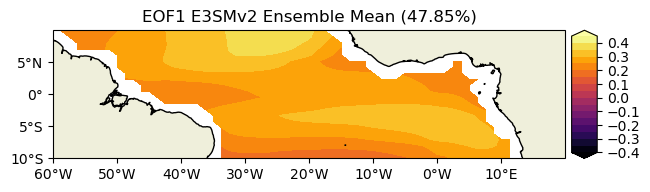

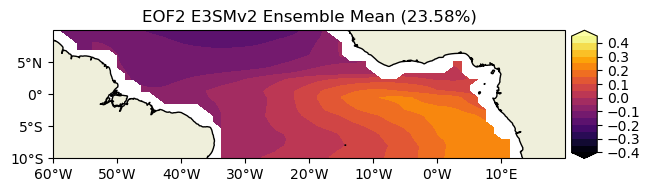

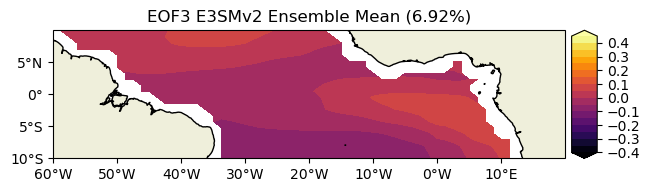

In [20]:
ens_mean_EOF1 = scaled_EOF.sel(mode=1).mean(dim='member')
ens_mean_xvar1 = EOF_members['ex_var'].sel(mode=1).mean(dim='member')
ens_mean_EOF2 = scaled_EOF.sel(mode=2).mean(dim='member')
ens_mean_xvar2 = EOF_members['ex_var'].sel(mode=2).mean(dim='member')
ens_mean_EOF3 = scaled_EOF.sel(mode=3).mean(dim='member')
ens_mean_xvar3 = EOF_members['ex_var'].sel(mode=3).mean(dim='member')


ds_map(ens_mean_EOF1, name=f'EOF1 E3SMv2 Ensemble Mean ({ens_mean_xvar1 * 100:.2f}%)')
ds_map(ens_mean_EOF2, name=f'EOF2 E3SMv2 Ensemble Mean ({ens_mean_xvar2 * 100:.2f}%)')
ds_map(ens_mean_EOF3, name=f'EOF3 E3SMv2 Ensemble Mean ({ens_mean_xvar3 * 100:.2f}%)')

In [21]:
scaled_EOF

<xarray.DataArray (member: 21, mode: 3, lat: 22, lon: 65)> Size: 721kB
array([[[[        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         ...,
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,  0.20330203, ...,         nan,
                  nan,         nan],
         [        nan,  0.19571982,  0.20087123, ...,         nan,
                  nan,         nan]],

        [[        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
...
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,  0.21028838, ...,         nan,
                  nan,         nan],
         [        nan,  0.20889084,  0.21404612, ...,         nan,
                  nan,         nan]],

        [[        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         ...,
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,  0.07705122, ...,         nan,
                  nan,         nan],
         [        nan,  0.07854498,  0.07896131, ...,         nan,
                  nan,         nan]]]])
Coordinates:
  * lat      (lat) float64 176B -9.895 -8.953 -8.01 -7.068 ... 8.01 8.953 9.895
  * lon      (lon) float64 520B -60.0 -58.75 -57.5 -56.25 ... 17.5 18.75 20.0
  * mode     (mode) int64 24B 1 2 3
  * member   (member) int64 168B 0 1 2 3 4 5 6 7 8 ... 13 14 15 16 17 18 19 20
Attributes: (12/15)
    model:          EOF analysis
    software:       xeofs
    version:        3.0.4
    date:           2025-09-05 07:19:57
    n_modes:        3
    center:         True
    ...             ...
    sample_name:    sample
    feature_name:   feature
    random_state:   None
    compute:        True
    solver:         auto
    solver_kwargs:  {}

### Separate Members

/glade/derecho/scratch/acruz/tmp/ipykernel_28303/1823293331.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 1,


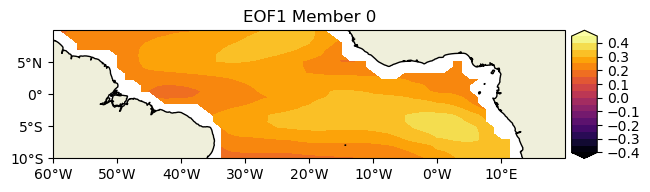

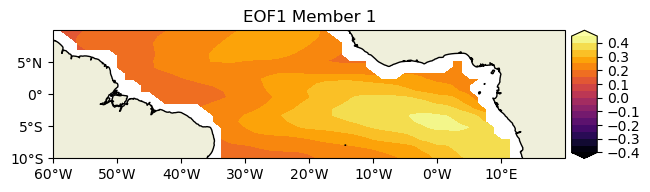

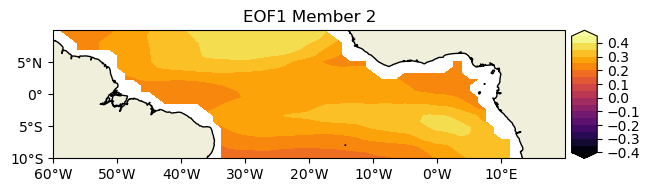

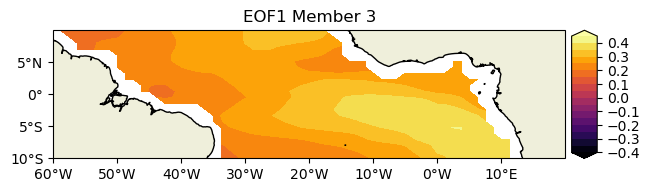

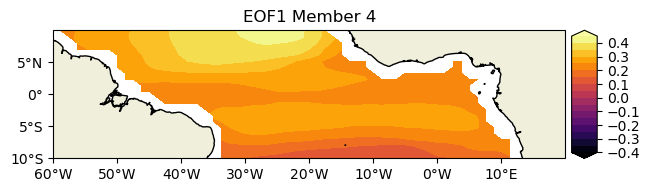

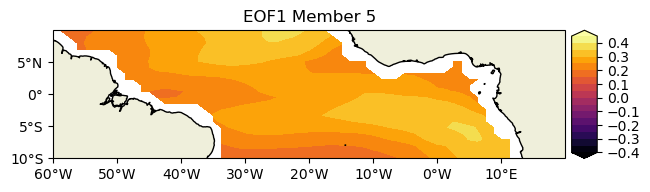

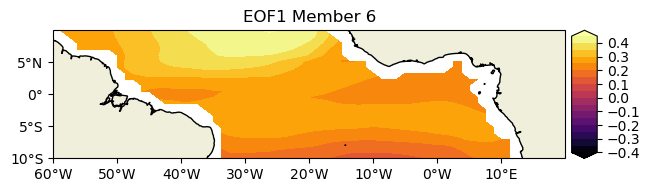

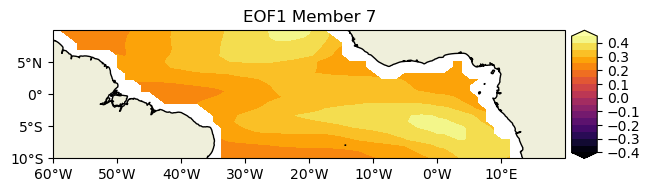

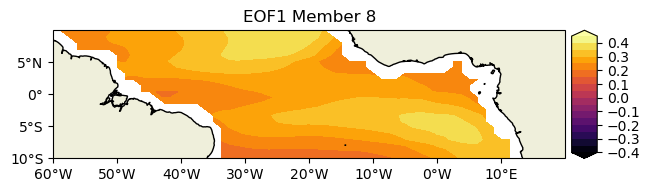

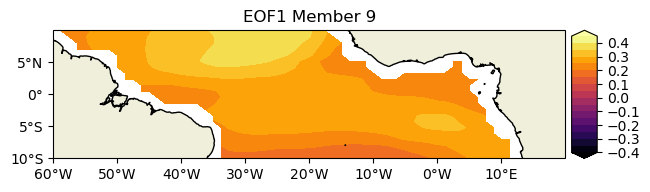

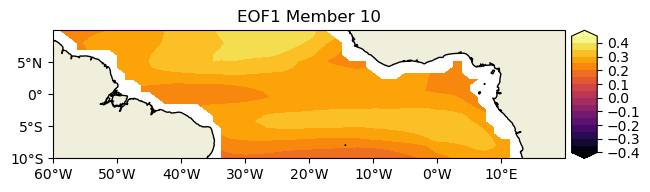

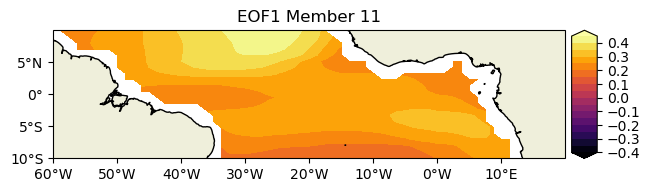

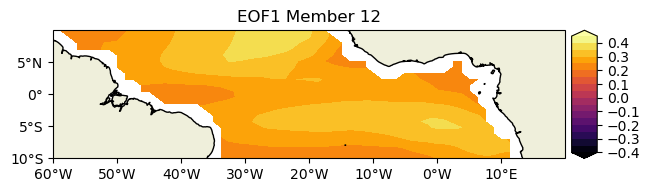

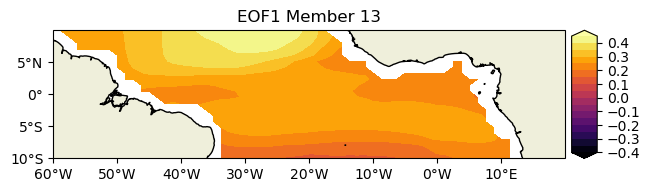

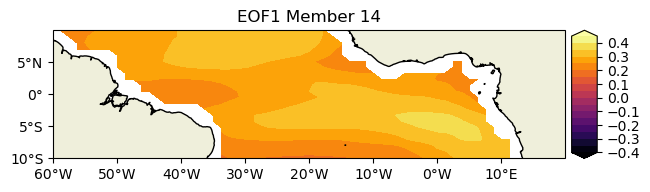

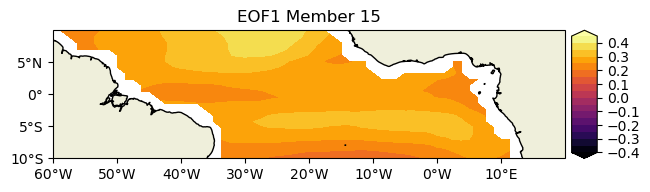

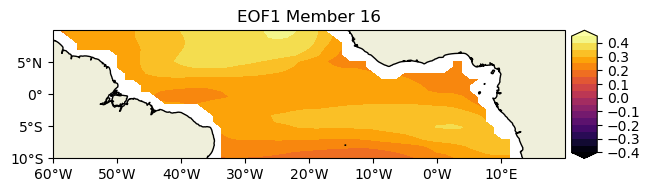

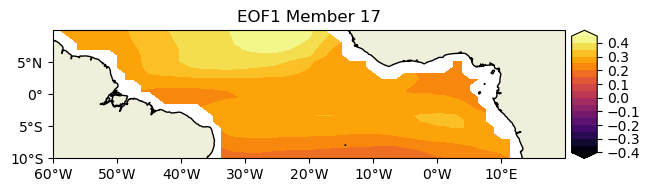

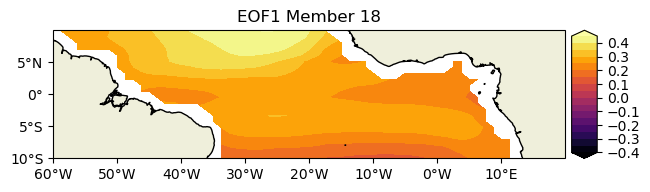

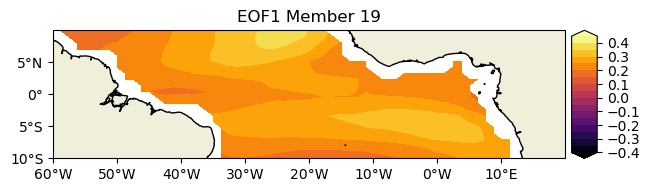

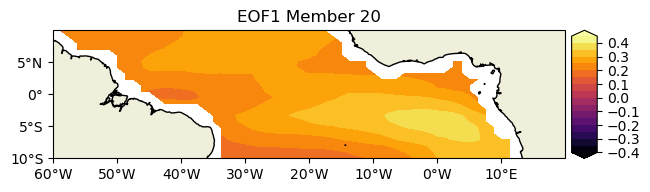

In [33]:
figs = []
axs = []
for m in scaled_EOF.member.values:
    fig , ax = ds_map(scaled_EOF.isel(member=m, mode=0), name=f'EOF1 Member {m}')
    figs.append(fig)
    axs.append(ax)

/glade/derecho/scratch/acruz/tmp/ipykernel_28303/1823293331.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 1,


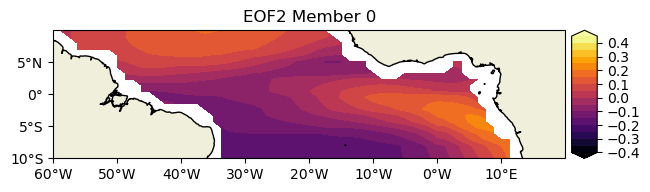

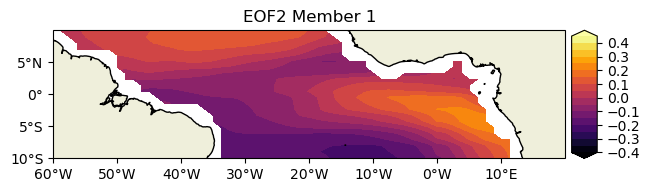

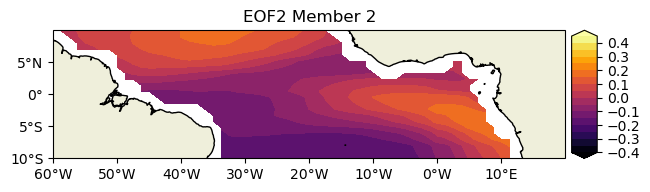

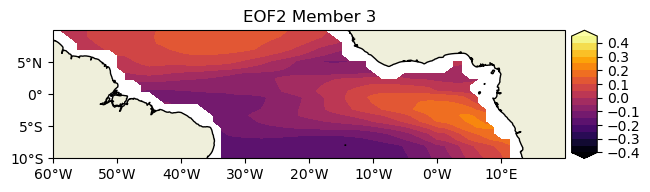

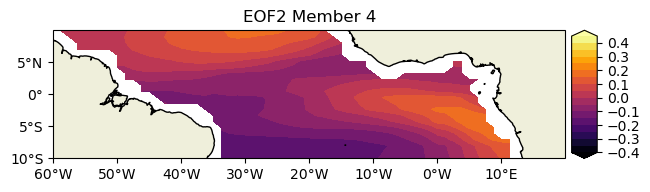

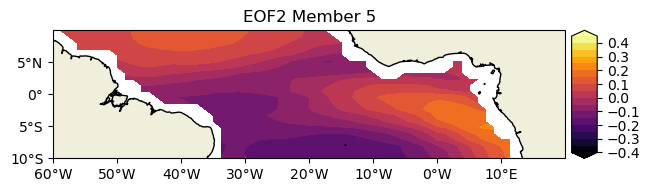

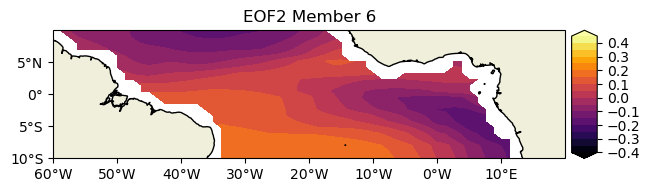

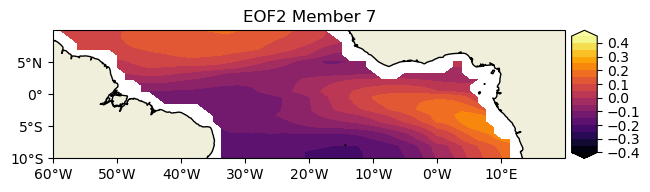

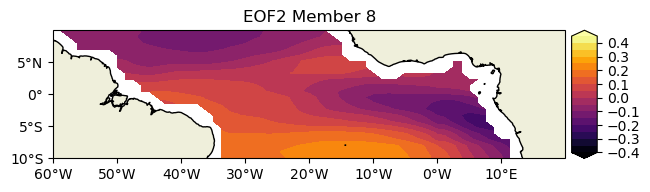

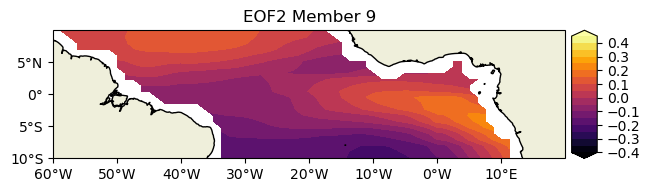

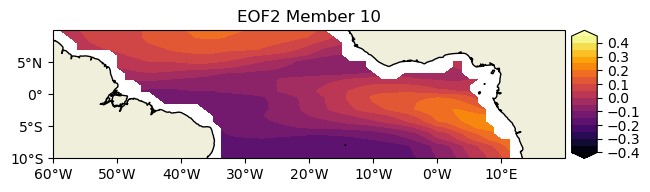

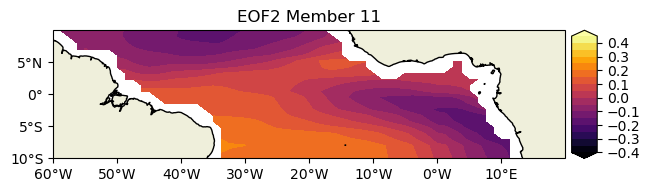

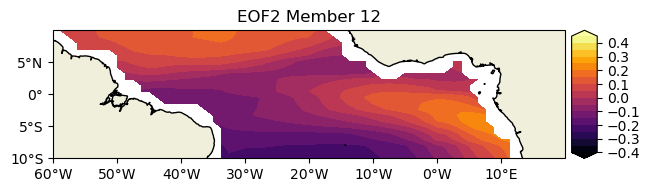

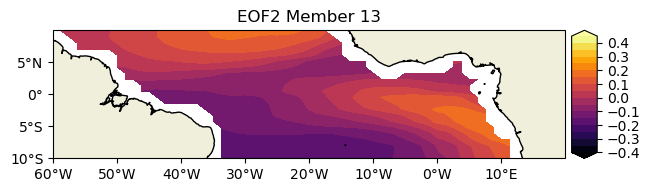

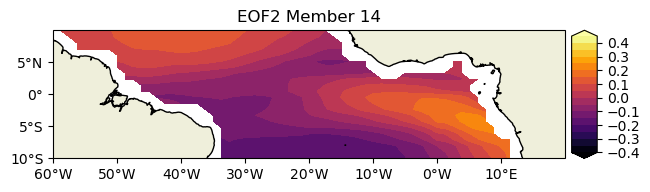

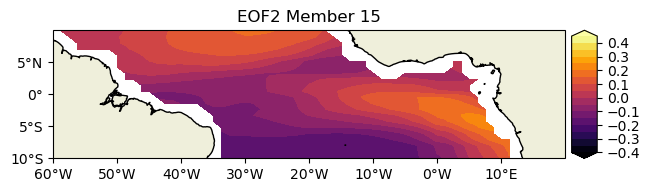

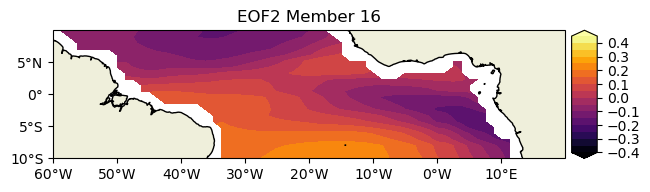

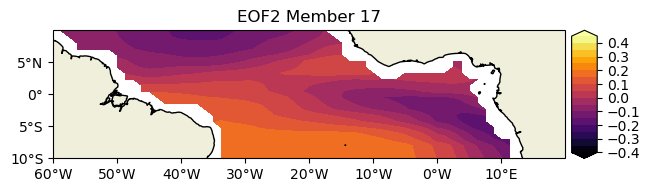

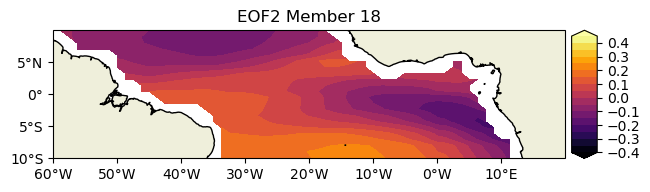

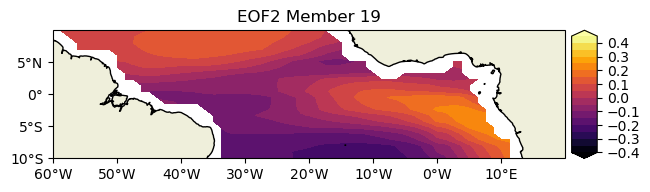

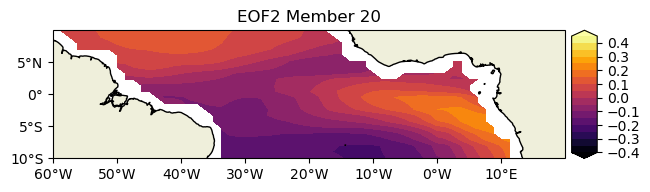

In [31]:
figs = []
axs = []
for m in scaled_EOF.member.values:
    fig , ax = ds_map(scaled_EOF.isel(member=m, mode=1), name=f'EOF2 Member {m}')
    figs.append(fig)
    axs.append(ax)

/glade/derecho/scratch/acruz/tmp/ipykernel_28303/1823293331.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 1,


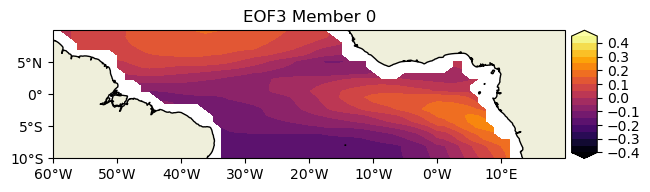

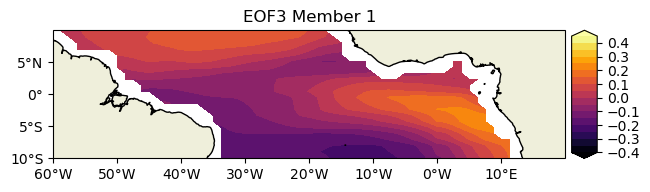

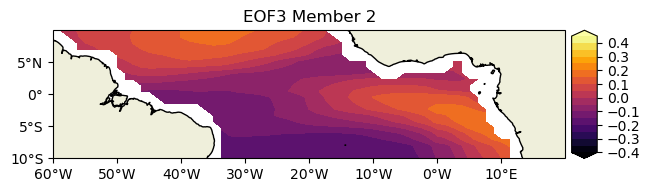

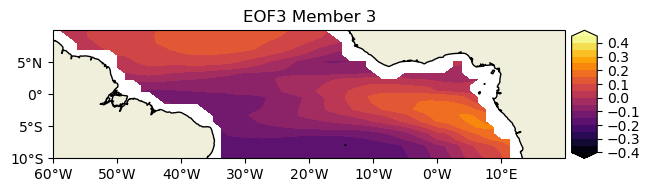

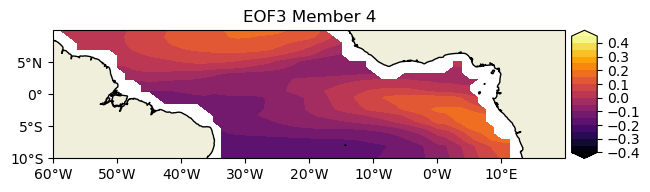

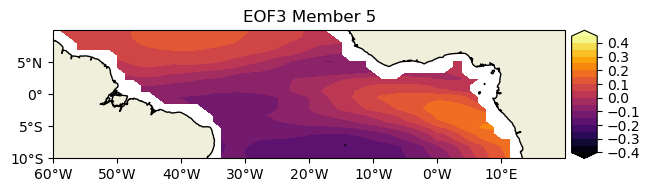

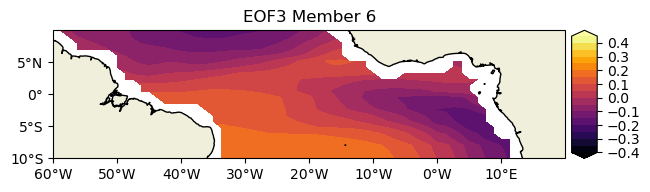

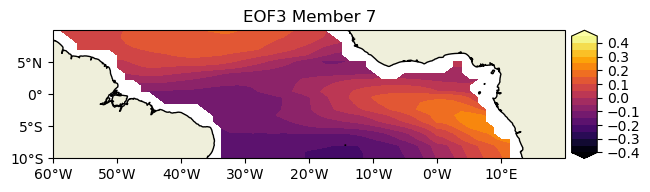

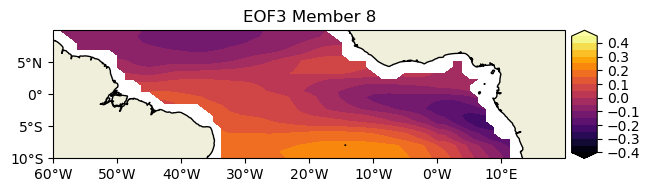

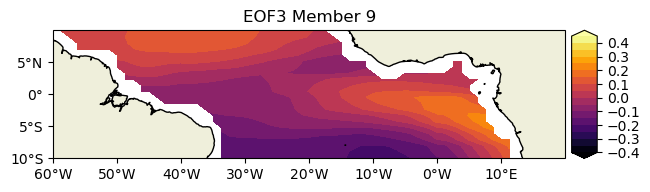

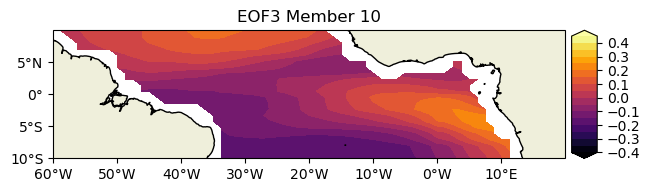

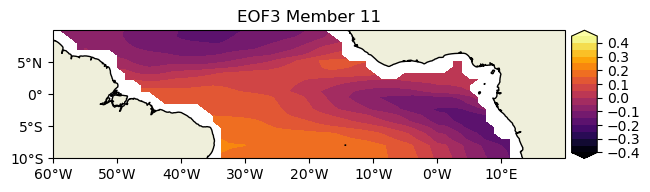

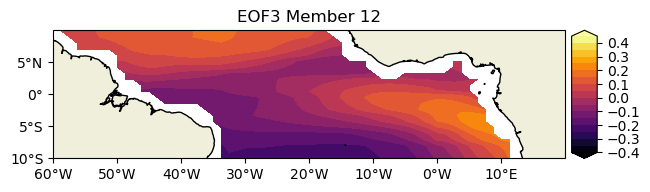

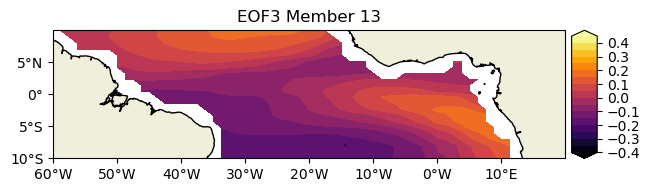

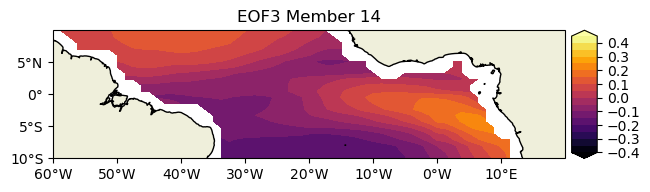

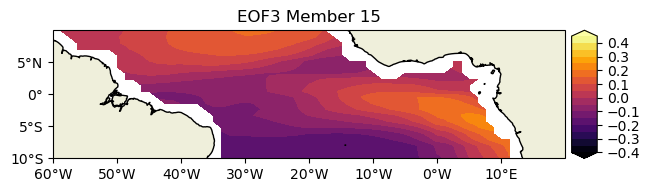

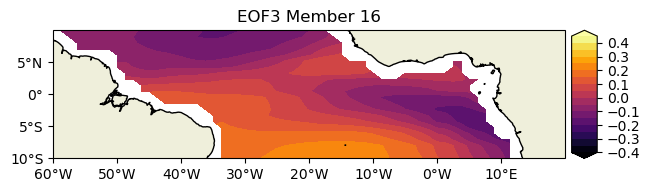

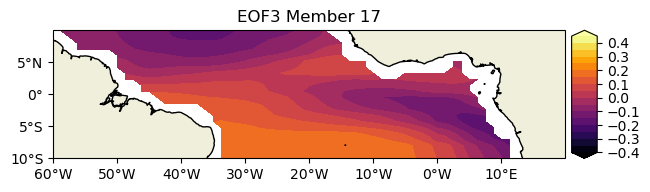

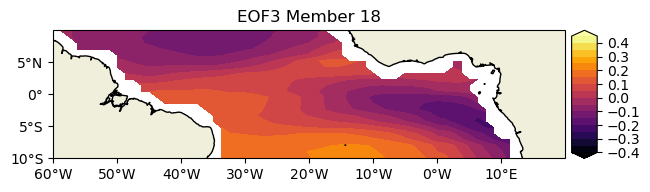

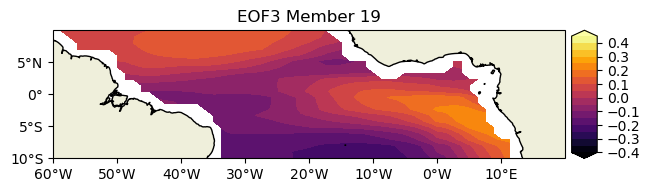

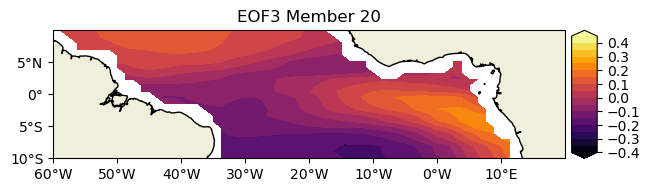

In [34]:
figs = []
axs = []
for m in scaled_EOF.member.values:
    fig , ax = ds_map(scaled_EOF.isel(member=m, mode=2), name=f'EOF3 Member {m}')
    figs.append(fig)
    axs.append(ax)

### CAN and EAN ensemble mean

(<Figure size 640x480 with 2 Axes>,
 <GeoAxes: title={'center': 'CAN E3SMv2 Ensemble Mean'}>)

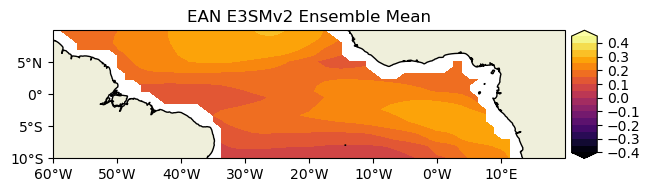

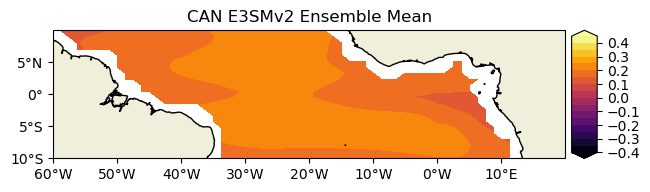

In [35]:
ens_mean_EAN = EAN.mean(dim='member')
ens_mean_CAN = CAN.mean(dim='member')

ds_map(ens_mean_EAN, name='EAN E3SMv2 Ensemble Mean')
ds_map(ens_mean_CAN, name='CAN E3SMv2 Ensemble Mean')

## Variance

### ensemble mean of eastern with ensemble mean of central through time

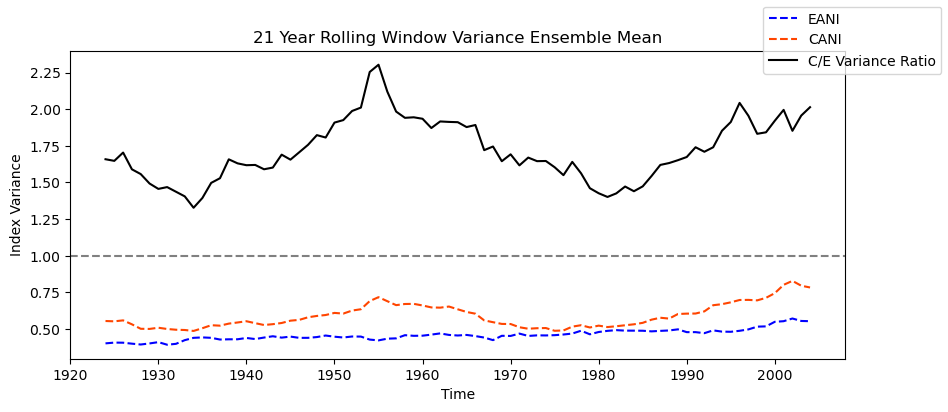

In [26]:
ens_CvE = CvE_r.mean(dim='member')
ens_EANIvar = EANI_var.mean(dim='member')
ens_CANIvar = CANI_var.mean(dim='member')

fig , ax1 = plt.subplots(figsize=(10, 4))

ens_EANIvar.plot(ax=ax1, label='EANI',  color='blue', linestyle='--')
ens_CANIvar.plot(ax=ax1, label='CANI',  color='orangered', linestyle='--')
ens_CvE.plot(ax=ax1, label='C/E Variance Ratio', color='black')
plt.title(f'21 Year Rolling Window Variance Ensemble Mean')
plt.ylabel('Index Variance')
plt.xlabel('Time')
ax1.axhline(1, color='grey', ls='--')
fig.legend()

### Eastern and central plot including all members and ensemble mean

### EANI

Text(0.5, 0, 'Year')

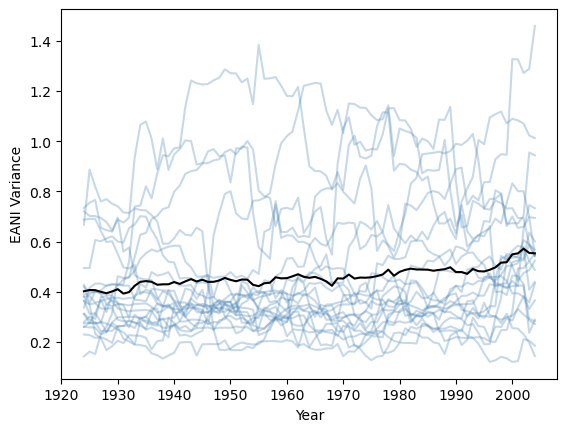

In [27]:
EANI_var.plot.line(hue='member', x='year', alpha=0.3, add_legend=False, color='steelblue')
ens_EANIvar.plot.line(color='black')
plt.ylabel('EANI Variance')
plt.xlabel('Year')

### CANI

Text(0.5, 0, 'Year')

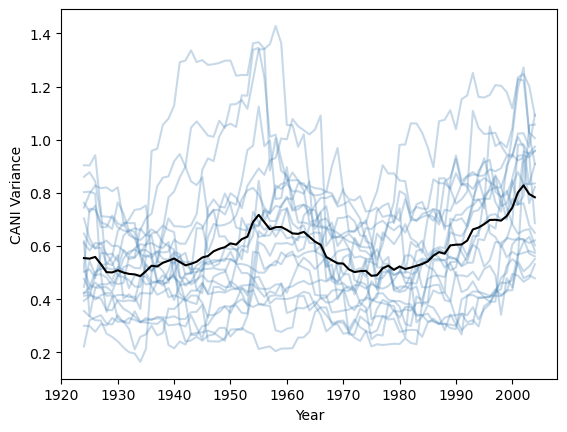

In [28]:
CANI_var.plot.line(hue='member', alpha=0.3, add_legend=False, color='steelblue')
ens_CANIvar.plot.line(color='black')
plt.ylabel('CANI Variance')
plt.xlabel('Year')

# Export

In [ ]:
EANI_roll = EANI_roll.drop_attrs()
CANI_roll = CANI_roll.drop_attrs()

In [ ]:
'''Data to export to regress with precipitation
CANI (time, members)
EANI (time, members)
call the values remove all weird attributes, and make a new dataset to export from there
'''
timeseries = xr.Dataset(
    data_vars={
                "EANI": EANI_roll,
                "CANI": CANI_roll
               },
    coords={"time": EANI_roll['time'].values}
)

timeseries.attrs.update({
    "title": "Atlantic Niño Index Timeseries",
    "description": f"Contains EANI, CANI calculated from CESM2.1 LE2",
    "created": "2025-09-04"
})
timeseries

In [ ]:
timeseries = timeseries.drop_indexes(('member', 'time'))
timeseries

In [ ]:
timeseries.to_netcdf("/glade/work/acruz/E3SMv2LE/EANI_CANI_E3SMv2.nc")